# Reranking

In this notebook we will not tune the model further. We will look at the final embeddings and how we can improve the similarity measure for them. Therefore we want to test whether **k-reciprocal-reranking** will increase the identity-balanced mAP on the validation and finally on the test set.

We use the results from our previous notebooks for the training pipeline:
- **Blurred backgrounds** (see [Background Interventions Notebook](01_background_interventions.ipynb))
- **DINOv3** backbone (see [Backbone Notebook](02_backbone.ipynb))
- Combined **ProxyAnchor + Center Loss** (see [Loss Combined Notebook](04_loss_combined.ipynb))
- **AdamW** optimizer (see [Optimizer Notebook](05_optimizers.ipynb))
- **OneCycleLR** scheduler (see [Scheduler Notebook](06_scheduler.ipynb))
- Class balancing via a generated samples (see [Class Balance Notebook](07_class_balance.ipynb))
- Configuration from best hyperparameter sweep run (see [Sweep Notebook](08b_sweep.ipynb))


## 1. Setup and Configuration

This section defines the required imports and configuration settings used throughout the notebook. These include library dependencies and any global parameters.

In [1]:
EXPERIMENT_NAME = "09_reranking"
RANDOM_SEED = 35 # 2, 35, 78, 56, 432

# -----------------------------
# Environment setup
# -----------------------------
import os
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

# -----------------------------
# Standard library imports
# -----------------------------
from dotenv import load_dotenv
from itertools import product
from joblib import Parallel, delayed
from pathlib import Path
import random
import sys

# -----------------------------
# Third-party libraries
# -----------------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics.pairwise import cosine_distances, cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tabulate import tabulate
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm
import wandb

import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

# -----------------------------
# Project path setup
# -----------------------------
PROJECT_PATH = Path.cwd().parent
sys.path.insert(0, str(PROJECT_PATH))

# -----------------------------
# Local modules
# -----------------------------
from src.criterions import (
    CenterLoss,
    CombinedLoss,
    ProxyAnchorLoss,
)
from src.datasets import BlurImageDataset, EmbeddingDataset
from src.models import EmbeddingProjection
from src.training import train_loop
from src.utils import (
    create_deterministic_training_dataloader,
    get_device,
    set_seeds,
    extract_embeddings, get_embeddings,
)
from src.visualization import (
    plot_history,
    visualize_embeddings_mds,
    visualize_nearest_neighbors,
)

# -----------------------------
# Reproducibility
# -----------------------------
set_seeds(RANDOM_SEED)
print(f"PyTorch version: {torch.__version__}")

All random seeds set to 35 for reproducibility
PyTorch version: 2.9.1+cu128


Define shared paths for the whole project.

In [2]:
# Define paths
DATA_PATH = PROJECT_PATH / "data"
OUTPUT_PATH = PROJECT_PATH / "output" / EXPERIMENT_NAME
OUTPUT_PATH_SHARED = PROJECT_PATH / "output" / "shared"
CHECKPOINT_PATH = PROJECT_PATH / "checkpoints" / EXPERIMENT_NAME
EMBEDDINGS_PATH = CHECKPOINT_PATH / "embeddings"

DATA_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH_SHARED.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

# Load environment variables from .env file
load_dotenv(dotenv_path=PROJECT_PATH / ".env")

True

In [3]:
# Configuration
config = {       
    # Dinov3 Model
    "dinov3_model": "hf-hub:timm/vit_base_patch16_dinov3.lvd1689m",
    "dinov3_input_size": 224,

    # Model
    "embedding_dim": 512,
    "hidden_dim": 768,
    "dropout": 0.1,
    
    # ProxyAnchor
    "proxyanchor_margin": 0.2,
    "proxyanchor_alpha": 16.0,
    "proxyanchor_lambda": 0.00001139770561131301,
    
    # AdamW
    "weight_decay": 0.00000655894766183814,
    "init_learning_rate": 0.00005403139355343448,
    
    # OneCycleLR
    "max_learning_rate": 0.007514589946885167,
    "pct_start": 0.2,

    # Training
    "batch_size": 32,
    "num_epochs": 200,
    "patience": 10,
    "val_split": 0.2,
    
    # Generate Augmentations
    "min_images_per_identity": 50,
    
    # Hyperparameter search for re-ranking
    "k1_list": list(range(5, 35, 1)),
    "k2_list": list(range(1, 15, 1)),
    "lambda_list": np.linspace(0.1, 0.6, 20).tolist(),
    "num_samples": 50,  # Number of random combinations to evaluate
    
    # Reproducibility
    "seed": RANDOM_SEED,
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  dinov3_model: hf-hub:timm/vit_base_patch16_dinov3.lvd1689m
  dinov3_input_size: 224
  embedding_dim: 512
  hidden_dim: 768
  dropout: 0.1
  proxyanchor_margin: 0.2
  proxyanchor_alpha: 16.0
  proxyanchor_lambda: 1.139770561131301e-05
  weight_decay: 6.55894766183814e-06
  init_learning_rate: 5.403139355343448e-05
  max_learning_rate: 0.007514589946885167
  pct_start: 0.2
  batch_size: 32
  num_epochs: 200
  patience: 10
  val_split: 0.2
  min_images_per_identity: 50
  k1_list: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]
  k2_list: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
  lambda_list: [0.1, 0.12631578947368421, 0.15263157894736842, 0.17894736842105263, 0.20526315789473684, 0.23157894736842105, 0.2578947368421053, 0.28421052631578947, 0.31052631578947365, 0.3368421052631579, 0.3631578947368421, 0.3894736842105263, 0.4157894736842105, 0.44210526315789467, 0.46842105263157896, 0.49473684210526

In [4]:
# Initialize Weights and Biases for experiment tracking
# Key hyperparameters are tracked explicitly for easy filtering in W&B dashboard
if not os.getenv("WANDB_API_KEY"):
    print("Warning: WANDB_API_KEY not found in environment variables. W&B logging will be disabled.")
else:
    wandb.login()

    wandb.init(
        project=os.getenv("WANDB_PROJECT", "jaguar-reid-karl-matti-schuetz"),
        config=config,
        name=EXPERIMENT_NAME,
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: karl-schuetz (karl-schuetz-hasso-plattner-institut) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Data Loading

In [5]:
# Load training data
train_df = pd.read_csv(DATA_PATH / "train.csv").set_index("filename")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
               ground_truth
filename                   
train_0001.png        Abril
train_0002.png        Abril
train_0003.png        Abril
train_0004.png       Akaloi
train_0005.png       Akaloi


Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


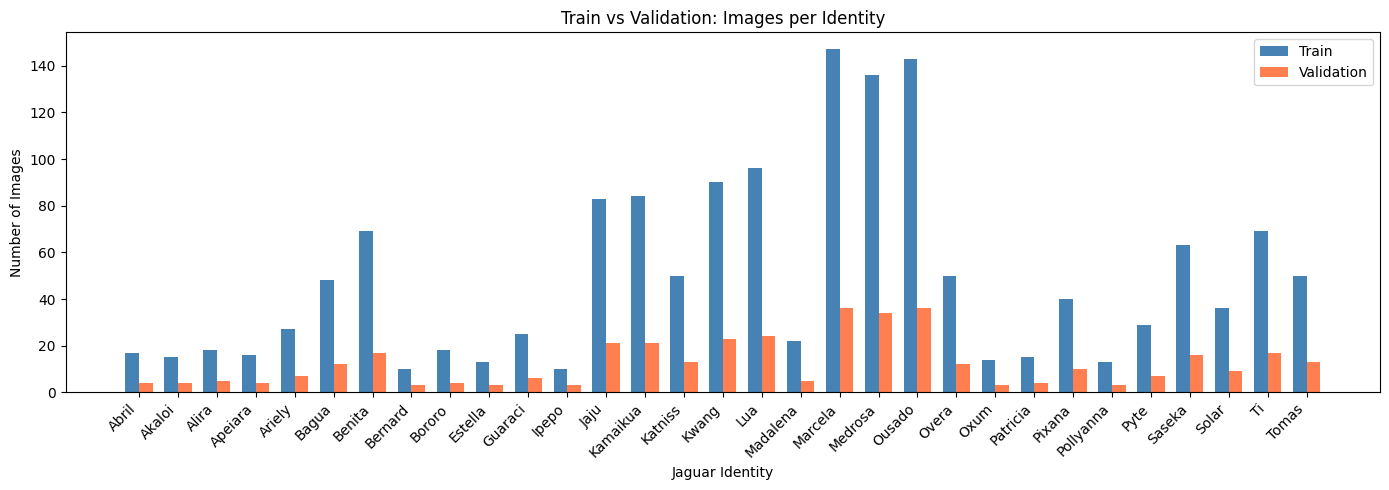


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [6]:
# Create stratified train/validation split
# This ensures all identities appear in both sets

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution": wandb.Image(fig)})
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

## Training Utils

In [7]:
device = get_device()
print(f"Using device: {device}")

num_workers = min(8, os.cpu_count())
print(f"Using num_workers={num_workers} for DataLoader")

Using CUDA GPU
Using device: cuda
Using num_workers=8 for DataLoader


In [8]:
filenames = train_df.index.astype(str)
train_mask = filenames.isin(train_data.index.astype(str))

filenames = filenames.to_numpy()
labels = train_df["label_encoded"].to_numpy()
image_paths = np.array([DATA_PATH / "train" / fn for fn in filenames])

train_labels = train_data.loc[filenames[train_mask], "label_encoded"].values
val_labels = val_data.loc[filenames[~train_mask], "label_encoded"].values

In [9]:
# Load Dino model
print("Loading Dino model...")
dino = timm.create_model(
    config["dinov3_model"],
    pretrained=True
)
dino.eval()
dino.to(device)
dino.compile()

dino_config = resolve_data_config({}, model=dino)
dino_preprocess = create_transform(**dino_config, is_training=False)

dino_num_params = sum(p.numel() for p in dino.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {dino_num_params:,}")
print(f"  Preprocessing: {dino_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = dino_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = dino(dummy_input)
    dino_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {dino_dim}")
    
wandb.log({
    "dino_num_params": dino_num_params,
    "dino_embedding_dim": dino_dim,
    "dino_input_size": dino_config["input_size"],
    "dino_preprocessing": str(dino_config),
})

Loading Dino model...
Model loaded successfully
  Parameters: 85,641,216
  Preprocessing: {'input_size': [3, 256, 256], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 1.0, 'crop_mode': 'center'}
  Embedding dimension: 768


We use the augmentations from the [Class Balance Notebook](07_class_balance.ipynb) to generate additional samples for underrepresented identities.

In [10]:
augment = transforms.Compose([
    # Randomly flip images horizontally; mimic different side of jaguar
    transforms.RandomHorizontalFlip(),

    # Crop and resize randomly to simulate different distances and framing
    transforms.RandomResizedCrop(dino_dim, scale=(0.85, 1.0)),

    # Small rotations to account for camera angle variation without distorting fur patterns
    transforms.RandomRotation(15),

    # Slight affine transformation: translation and scaling to simulate animal movement
    transforms.RandomAffine(
        degrees=0,           # no extra rotation
        translate=(0.05, 0.05),
        scale=(0.9, 1.1)
    ),

    # Subtle color changes to mimic lighting variation; avoid distorting natural fur
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.05
    ),

    # Apply slight blur to simulate motion blur or out-of-focus shots
    transforms.GaussianBlur(5, sigma=(0.1, 1.0)),
])

In [11]:
augment_dir = OUTPUT_PATH / "augmented_data"
os.makedirs(augment_dir, exist_ok=True)

train_image_paths = np.array(image_paths)[train_mask]

augmented_paths = []
augmented_labels = []

min_images_per_identity = config["min_images_per_identity"]

for label in tqdm(range(num_classes), desc="Augmenting classes"):

    mask = train_labels == label
    label_paths = train_image_paths[mask]
    needed = max(0, min_images_per_identity - len(label_paths))

    print(f"Class {label}: {len(label_paths)} samples, need {needed} more")

    for i in range(needed):

        img_path = random.choice(label_paths)
        filename = img_path.stem
        
        # Use filename to hinder data leakage from previous runs on validation set
        save_path = augment_dir / f"class{label}_aug_{filename}.png"

        # # To save computation, we only compute images once.
        # if not save_path.exists():
        img = Image.open(img_path).convert("RGBA")
        aug_img = augment(img)
        aug_img.save(save_path)

        augmented_paths.append(save_path)
        augmented_labels.append(label)

augmented_paths = np.array(augmented_paths)
augmented_labels = np.array(augmented_labels)

combined_train_paths = np.concatenate([train_image_paths, augmented_paths])
combined_train_labels = np.concatenate([train_labels, augmented_labels])

combined_train_filenames = np.array([p.name for p in combined_train_paths])

Augmenting classes:   0%|          | 0/31 [00:00<?, ?it/s]

Class 0: 17 samples, need 33 more


Augmenting classes:   3%|▎         | 1/31 [00:13<06:59, 13.99s/it]

Class 1: 15 samples, need 35 more


Augmenting classes:   6%|▋         | 2/31 [00:27<06:30, 13.46s/it]

...

Class 26: 29 samples, need 21 more


Augmenting classes:  87%|████████▋ | 27/31 [04:12<00:38,  9.56s/it]

Class 27: 63 samples, need 0 more
Class 28: 36 samples, need 14 more


Augmenting classes: 100%|██████████| 31/31 [04:20<00:00,  8.39s/it]

Class 29: 69 samples, need 0 more
Class 30: 50 samples, need 0 more


In [12]:
val_paths = np.array(image_paths)[~train_mask]
val_filenames = np.array([p.name for p in val_paths])

all_paths = np.concatenate([combined_train_paths, val_paths])
all_filenames = np.concatenate([combined_train_filenames, val_filenames])

all_labels = np.concatenate([combined_train_labels, val_labels])

image_dataset = BlurImageDataset(
    all_paths,
    preprocess_fn=dino_preprocess
)
image_loader = DataLoader(
    image_dataset,
    batch_size=32,
    num_workers=num_workers,
    shuffle=False,
    pin_memory=True,
)

print(f"Image DataLoader created with {len(image_loader)} batches")

Image DataLoader created with 76 batches


In [13]:
baseline_cache_path = OUTPUT_PATH / "dino_blur_embeddings_augmented.npz"

baseline_embeddings = get_embeddings(
    model=dino,
    cache_path=baseline_cache_path,
    data_loader=image_loader,
    filenames=all_filenames,
    device=device
)

Extracting embeddings for 76 images...


Extracting embeddings:   0%|          | 0/76 [00:00<?, ?it/s]

Extracting embeddings: 100%|██████████| 76/76 [11:01<00:00,  8.70s/it] 


Saved embeddings cache to /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/09_reranking/dino_blur_embeddings_augmented.npz
Embeddings shape: (2409, 768)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


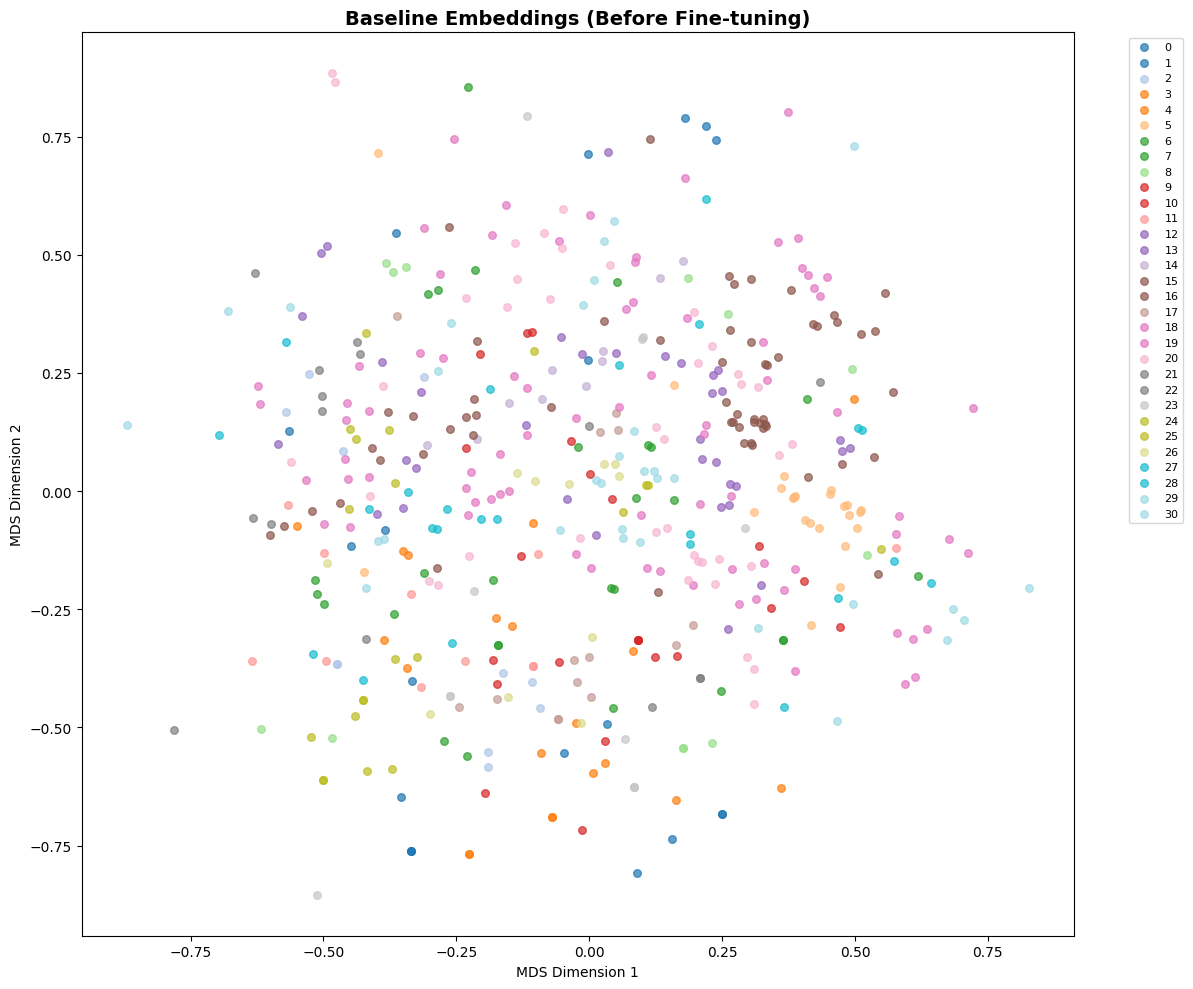

In [14]:
# Visualize DINO embeddings
fig = visualize_embeddings_mds(
    baseline_embeddings,
    all_labels,
    "Baseline Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "baseline_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"baseline_embeddings_mds": wandb.Image(fig)})

In [15]:
# Train Dataset contains real and augmented images
baseline_emb_train_dataset = EmbeddingDataset(
    baseline_embeddings[:len(combined_train_paths)],
    combined_train_labels
)

baseline_emb_val_dataset = EmbeddingDataset(
    baseline_embeddings[len(combined_train_paths):],
    val_labels
)

baseline_emb_train_loader = create_deterministic_training_dataloader(
    baseline_emb_train_dataset,
    batch_size=config["batch_size"],
    seed=config['seed'],
    num_workers=num_workers,
    
)
baseline_emb_val_loader = DataLoader(
    baseline_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

In [16]:
# Create model
model = EmbeddingProjection(
    input_dim=dino_dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

wandb.log({"num_projection_params": sum(p.numel() for p in model.parameters())})

model.print_model_summary()

Embedding Projection:
  Input dim: 768
  Hidden dim: 768
  Output dim: 512
  Dropout: 0.1
  Total parameters: 986880


In [17]:
criterion = CombinedLoss(
    first_loss=CenterLoss(
        num_classes=num_classes, 
        embedding_dim=config["embedding_dim"]
    ),
    second_loss=ProxyAnchorLoss(
        num_classes=num_classes, 
        embedding_dim=config["embedding_dim"], 
        margin=config["proxyanchor_margin"], 
        alpha=config["proxyanchor_alpha"]
    ),
    lambda_center=config["proxyanchor_lambda"]
).to(device)

print(f"Combined Loss: CenterLoss + ProxyAnchor")
print(f"  ProxyAnchor margin: {config['proxyanchor_margin']}")
print(f"  ProxyAnchor alpha: {config['proxyanchor_alpha']}")
print(f"  Lambda: {config['proxyanchor_lambda']}")

Combined Loss: CenterLoss + ProxyAnchor
  ProxyAnchor margin: 0.2
  ProxyAnchor alpha: 16.0
  Lambda: 1.139770561131301e-05


In [18]:
# Setup training components
optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["init_learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=config["max_learning_rate"],
    epochs=config["num_epochs"],
    steps_per_epoch=len(baseline_emb_train_loader),
    pct_start=config["pct_start"],
    anneal_strategy='cos',
    cycle_momentum=False,
)

print("Training components initialized:")
print(f"  Optimizer: Adam (lr={config['init_learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: OneCycleLR (max_lr={config['max_learning_rate']}, epochs={config['num_epochs']}, steps_per_epoch={len(baseline_emb_train_loader)}, pct_start={config['pct_start']})")

Training components initialized:
  Optimizer: Adam (lr=5.403139355343448e-05, weight_decay=6.55894766183814e-06)
  Scheduler: OneCycleLR (max_lr=0.007514589946885167, epochs=200, steps_per_epoch=64, pct_start=0.2)


In [19]:
table = [
    ["Strategy", "val_mAP", "full_mAP"]
]

We need to train only one model for comparison.

In [20]:
# Training loop
set_seeds(config['seed'])
checkpoint_path = CHECKPOINT_PATH / "best_model.pth"
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="model",
    checkpoint_path=checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)

wandb.log({
    "final_val_mAP": best_map,
    "best_epoch": best_epoch,
    "total_epochs": len(history['train_loss']),
})

All random seeds set to 35 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


Training:   0%|          | 0/64 [00:00<?, ?it/s]

  Train Loss: 816.5663
  Val Loss:   585.6655
  Val mAP:    0.4072 | LR: 3.12e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 545.6759
  Val Loss:   418.7845
  Val mAP:    0.4963 | LR: 3.45e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 402.5014
  Val Loss:   321.5507
  Val mAP:    0.5997 | LR: 4.00e-04
  [New best model saved]

Epoch 4/200


...

  Train Loss: 10.6237
  Val Loss:   16.6761
  Val mAP:    0.8884 | LR: 6.65e-03
  No improvement. Patience: 6/10

Epoch 32/200


  Train Loss: 9.1572
  Val Loss:   14.5923
  Val mAP:    0.8850 | LR: 6.83e-03
  No improvement. Patience: 7/10

Epoch 33/200


  Train Loss: 8.5896
  Val Loss:   13.2646
  Val mAP:    0.8847 | LR: 6.98e-03
  No improvement. Patience: 8/10

Epoch 34/200


  Train Loss: 7.4526
  Val Loss:   11.7313
  Val mAP:    0.8892 | LR: 7.12e-03
  No improvement. Patience: 9/10

Epoch 35/200


  Train Loss: 6.3784
  Val Loss:   10.2393
  Val mAP:    0.8875 | LR: 7.24e-03
  No improvement. Patience: 10/10

Early stopping triggered after 35 epochs

Training complete!
Best epoch: 25, Val mAP: 0.8955


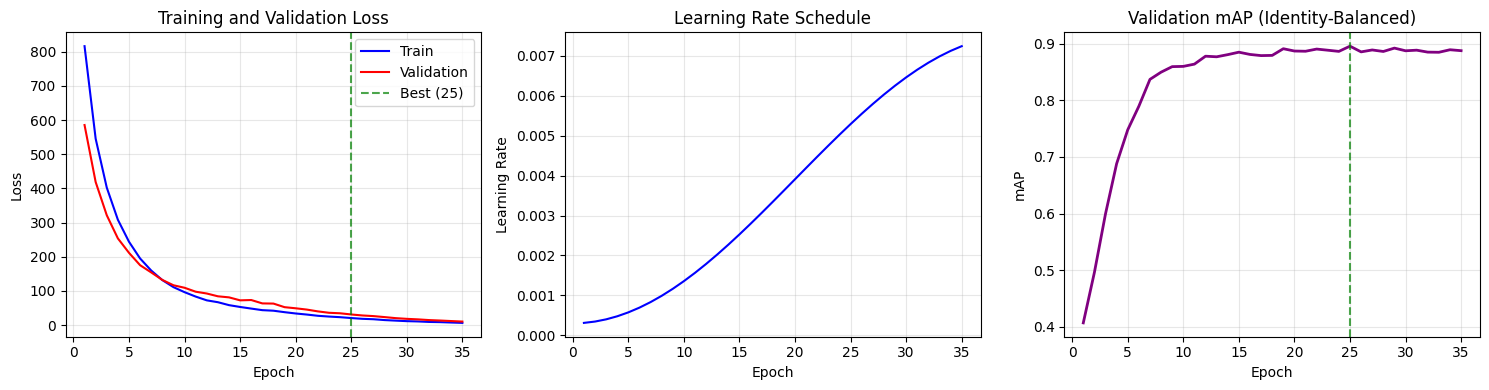

In [21]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves": wandb.Image(fig)})

In [22]:
# Load best model
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 25
  Val Loss: 31.0140
  Val mAP: 0.8955


In [23]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (2409, 512)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


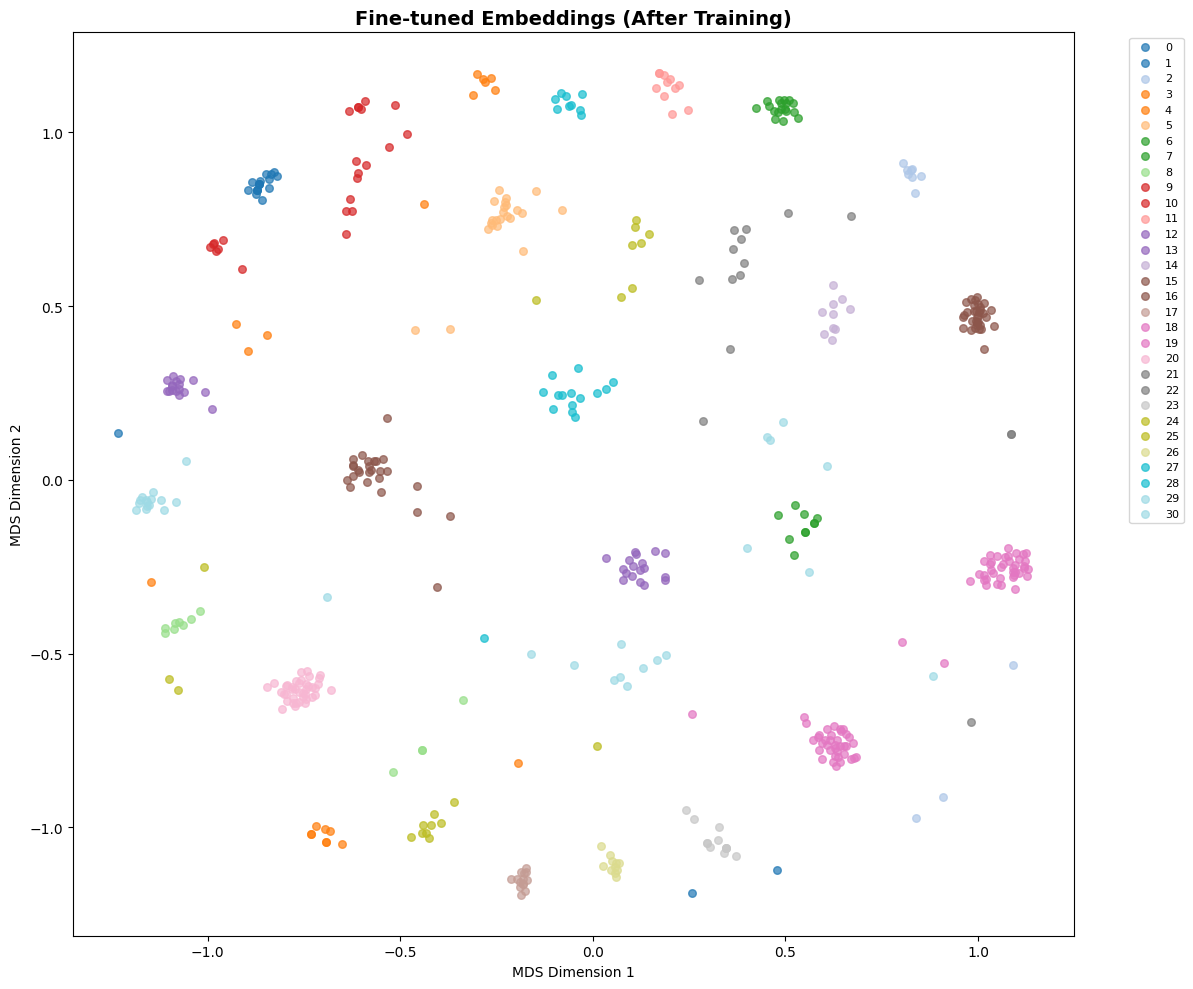

In [24]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    all_labels,
    "Fine-tuned Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds": wandb.Image(fig_finetuned)})

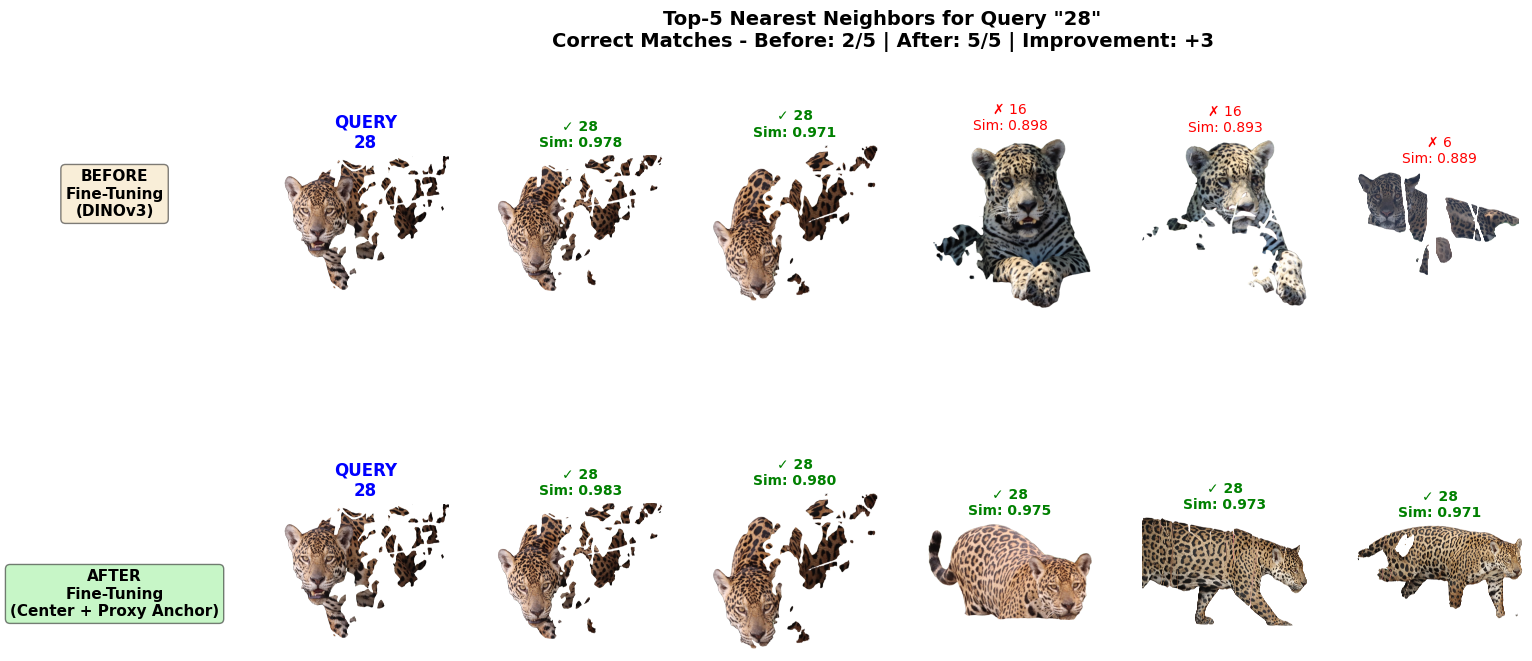

In [25]:
random_idx = np.random.randint(0, len(val_labels))
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=baseline_embeddings[len(combined_train_paths):],
    finetuned_embeddings=finetuned_embeddings[len(combined_train_paths):],
    image_paths=all_paths[len(combined_train_paths):],
    labels=val_labels,
    before_label='BEFORE\nFine-Tuning\n(DINOv3)',
    after_label='AFTER\nFine-Tuning\n(Center + Proxy Anchor)'
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors": wandb.Image(fig),
    "nearest_neighbors_stats": stats,
})


In [26]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Strategy Comparison for Default Parameters

In this section, we evaluate the impact of **k-reciprocal reranking** using the parameters specified in the Q&A document.


In [27]:
def k_reciprocal_rerank(features, k1=20, k2=6, lambda_value=0.3):

    original_dist = cosine_distances(features, features)
    all_num = original_dist.shape[0]

    # Normalize
    # original_dist = original_dist / np.max(original_dist, axis=0)
    original_dist = original_dist / np.max(original_dist, axis=1, keepdims=True)
    V = np.zeros_like(original_dist).astype(np.float32)

    initial_rank = np.argsort(original_dist).astype(np.int32)

    for i in range(all_num):

        forward_k_neigh_index = initial_rank[i, :k1+1]
        backward_k_neigh_index = initial_rank[forward_k_neigh_index, :k1+1]

        fi = np.where(backward_k_neigh_index == i)[0]
        k_reciprocal_index = forward_k_neigh_index[fi]

        k_reciprocal_expansion_index = k_reciprocal_index

        for candidate in k_reciprocal_index:
            candidate_forward = initial_rank[candidate, :int(np.around(k1/2))+1]
            candidate_backward = initial_rank[candidate_forward, :int(np.around(k1/2))+1]

            fi_candidate = np.where(candidate_backward == candidate)[0]
            candidate_k_reciprocal = candidate_forward[fi_candidate]

            if len(np.intersect1d(candidate_k_reciprocal, k_reciprocal_index)) > 2/3 * len(candidate_k_reciprocal):
                k_reciprocal_expansion_index = np.append(
                    k_reciprocal_expansion_index, candidate_k_reciprocal
                )

        k_reciprocal_expansion_index = np.unique(k_reciprocal_expansion_index)

        # weight = np.exp(-original_dist[i, k_reciprocal_expansion_index])
        weight = 1 - original_dist[i, k_reciprocal_expansion_index]  # instead of exp(-d)
        V[i, k_reciprocal_expansion_index] = weight / np.sum(weight)

    if k2 != 1:
        V_qe = np.zeros_like(V)
        for i in range(all_num):
            V_qe[i] = np.mean(V[initial_rank[i, :k2]], axis=0)
        V = V_qe

    invIndex = []
    for i in range(all_num):
        invIndex.append(np.where(V[:, i] != 0)[0])

    jaccard_dist = np.zeros_like(original_dist)

    for i in range(all_num):
        temp_min = np.zeros((1, all_num))

        indNonZero = np.where(V[i] != 0)[0]

        for j in indNonZero:
            temp_min[0, invIndex[j]] += np.minimum(V[i, j], V[invIndex[j], j])

        jaccard_dist[i] = 1 - temp_min / (2 - temp_min)

    final_dist = jaccard_dist * (1 - lambda_value) + original_dist * lambda_value

    return final_dist

We redefine the `compute_validation_map` function to include an option for reranking the embeddings. Reranking is computed on the entire dataset, as this can help stabilize neighbor relationships and improve mAP.


In [28]:
def compute_validation_map(embeddings, selected_mask, labels, rerank=False, k1=20, k2=6, lambda_value=0.3):
    """
    Compute identity-balanced mean Average Precision.
    
    This simulates the competition metric:
    1. For each query, rank all other images by cosine similarity
    2. Compute Average Precision based on where true matches appear
    3. Average APs within each identity, then average across identities
    """
    model.eval()
    
    if rerank:
        dist_matrix = k_reciprocal_rerank(embeddings, k1=k1, k2=k2, lambda_value=lambda_value)
        # convert distance → similarity
        sim_matrix = -dist_matrix[selected_mask][:, selected_mask]
        # sim_matrix = -dist_matrix
    else:
        # Compute cosine similarity matrix
        sim_matrix = cosine_similarity(embeddings[selected_mask])
    
    np.fill_diagonal(sim_matrix, -1)  # Exclude self-similarity
        
    # Compute AP for each query
    query_aps = {}

    for query_idx in range(len(labels)):
        query_label = labels[query_idx]

        # Get similarities to all gallery images (excluding self)
        similarities = sim_matrix[query_idx]
        
        # True labels for gallery
        gallery_labels = labels.copy()
        is_match = (gallery_labels == query_label).astype(int)
        is_match[query_idx] = 0  # Exclude self
        
        # Sort by similarity descending
        sorted_indices = np.argsort(-similarities)
        sorted_matches = is_match[sorted_indices]
        
        # Compute Average Precision
        n_positives = sorted_matches.sum()
        if n_positives == 0:
            continue
        
        cumsum = np.cumsum(sorted_matches)
        precision_at_k = cumsum / np.arange(1, len(sorted_matches) + 1)
        ap = np.sum(precision_at_k * sorted_matches) / n_positives
        
        query_aps[query_idx] = (query_label, ap)
    
    # Group by identity and compute identity-balanced mAP
    identity_aps = {}
    for query_idx, (label, ap) in query_aps.items():
        if label not in identity_aps:
            identity_aps[label] = []
        identity_aps[label].append(ap)
    
    # Average within identity, then across identities
    identity_mean_aps = [np.mean(aps) for aps in identity_aps.values()]
    balanced_map = np.mean(identity_mean_aps)
    
    return balanced_map

In [30]:
def k_reciprocal_rerank2(features, k1=20, k2=6, lambda_value=0.3):
    """
    features: (N, D) numpy array (L2 normalized recommended)

    returns:
        final_dist (N, N)
    """

    original_dist = cosine_distances(features, features)
    original_dist = original_dist / np.max(original_dist, axis=1, keepdims=True)

    N = original_dist.shape[0]
    V = np.zeros_like(original_dist, dtype=np.float32)

    initial_rank = np.argsort(original_dist).astype(np.int32)

    for i in range(N):

        forward_k = initial_rank[i, :k1 + 1]
        backward_k = initial_rank[forward_k, :k1 + 1]

        fi = np.where(backward_k == i)[0]
        k_reciprocal = forward_k[fi]

        k_reciprocal_expansion = k_reciprocal.copy()

        for candidate in k_reciprocal:

            candidate_forward = initial_rank[candidate, :int(np.round(k1/2)) + 1]
            candidate_backward = initial_rank[candidate_forward, :int(np.round(k1/2)) + 1]

            fi_candidate = np.where(candidate_backward == candidate)[0]
            candidate_krec = candidate_forward[fi_candidate]

            if len(np.intersect1d(candidate_krec, k_reciprocal)) > 2/3 * len(candidate_krec):
                k_reciprocal_expansion = np.append(k_reciprocal_expansion, candidate_krec)

        k_reciprocal_expansion = np.unique(k_reciprocal_expansion)

        weight = np.exp(-original_dist[i, k_reciprocal_expansion])
        V[i, k_reciprocal_expansion] = weight / np.sum(weight)

    if k2 != 1:
        V_qe = np.zeros_like(V, dtype=np.float32)
        for i in range(N):
            V_qe[i] = np.mean(V[initial_rank[i, :k2]], axis=0)
        V = V_qe

    invIndex = []
    for i in range(N):
        invIndex.append(np.where(V[:, i] != 0)[0])

    jaccard_dist = np.zeros_like(original_dist, dtype=np.float32)

    for i in range(N):

        temp_min = np.zeros((1, N), dtype=np.float32)
        indNonZero = np.where(V[i] != 0)[0]

        for j in indNonZero:
            temp_min[0, invIndex[j]] += np.minimum(V[i, j], V[invIndex[j], j])

        jaccard_dist[i] = 1 - temp_min / (2 - temp_min)

    final_dist = (1 - lambda_value) * jaccard_dist + lambda_value * original_dist

    return final_dist

In [33]:
def average_precision(sorted_matches):
    """
    sorted_matches: binary array (1 if correct identity)
    """

    n_pos = sorted_matches.sum()
    if n_pos == 0:
        return None

    cumsum = np.cumsum(sorted_matches)
    precision = cumsum / (np.arange(len(sorted_matches)) + 1)

    ap = np.sum(precision * sorted_matches) / n_pos
    return ap


def compute_map(
    embeddings,
    labels,
    query_mask=None,
    rerank=False,
    k1=20,
    k2=6,
    lambda_value=0.3
):
    """
    embeddings : (N,D)
    labels     : (N,)
    query_mask : bool mask
    gallery_mask : bool mask

    If masks are None -> closed set retrieval.
    """

    embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)

    if query_mask is None:
        query_mask = np.ones(len(labels), dtype=bool)

    queries = embeddings[query_mask]
    gallery = embeddings[~query_mask]

    query_labels = labels[query_mask]
    gallery_labels = labels[~query_mask]

    if rerank:

        all_embeddings = np.concatenate([queries, gallery])
        dist = k_reciprocal_rerank2(all_embeddings, k1, k2, lambda_value)

        Nq = len(queries)
        sim_matrix = -dist[:Nq, Nq:]

    else:

        sim_matrix = cosine_similarity(queries, gallery)

    query_aps = {}

    for q_idx in range(len(query_labels)):

        similarities = sim_matrix[q_idx]

        matches = (gallery_labels == query_labels[q_idx]).astype(int)

        sorted_idx = np.argsort(-similarities)
        sorted_matches = matches[sorted_idx]

        ap = average_precision(sorted_matches)

        if ap is None:
            continue

        label = query_labels[q_idx]

        if label not in query_aps:
            query_aps[label] = []

        query_aps[label].append(ap)

    identity_means = [np.mean(v) for v in query_aps.values()]

    return np.mean(identity_means)

Computation for validation set.

In [35]:
val_mask = np.zeros(len(all_labels), dtype=bool)
val_mask[len(combined_train_paths):] = True
val_map_without_reranking = compute_map(finetuned_embeddings, all_labels, query_mask=val_mask, rerank=False)
print(f"Validation mAP without re-ranking: {val_map_without_reranking:.4f}")

val_map_with_reranking = compute_map(finetuned_embeddings, all_labels, query_mask=val_mask, rerank=True)
print(f"Validation mAP with re-ranking: {val_map_with_reranking:.4f}")

Validation mAP without re-ranking: 0.9300
Validation mAP with re-ranking: 0.9303


In [ ]:
val_mask = np.zeros(len(all_labels), dtype=bool)
val_mask[len(combined_train_paths):] = True
val_map_without_reranking = compute_validation_map(finetuned_embeddings, val_mask, val_labels, rerank=False)
print(f"Validation mAP without re-ranking: {val_map_without_reranking:.4f}")

val_map_with_reranking = compute_validation_map(finetuned_embeddings, val_mask, val_labels, rerank=True)
print(f"Validation mAP with re-ranking: {val_map_with_reranking:.4f}")

Computation for full set.

In [ ]:
full_mask = np.ones(len(all_labels), dtype=bool)
full_map_without_reranking = compute_validation_map(finetuned_embeddings, full_mask, all_labels, rerank=False)
print(f"Full mAP without re-ranking: {full_map_without_reranking:.4f}")

full_map_with_reranking = compute_validation_map(finetuned_embeddings, full_mask, all_labels, rerank=True)
print(f"Full mAP with re-ranking: {full_map_with_reranking:.4f}")

Full mAP without re-ranking: 0.9894
Full mAP with re-ranking: 0.9890


In [ ]:
table.append([
    "Without Re-ranking",
    f"{val_map_without_reranking:.4f}",
    f"{full_map_without_reranking:.4f}"
])
table.append([
    "With Re-ranking",
    f"{val_map_with_reranking:.4f}",
    f"{full_map_with_reranking:.4f}"
])

## k-reciprocal-reranking Hyperparameter Search

In this section, we try to find the best hyperparameters for **k-reciprocal-reranking** using a large grid search.

In [ ]:
result_path = OUTPUT_PATH / "reranking_hyperparameter_sweep.csv"

results = []

tested = set()  # To track tested combinations and avoid duplicates in random search

# Perform random search
for _ in tqdm(range(config["num_samples"]), desc="Random search for re-ranking hyperparameters"):
    k1 = random.choice(config["k1_list"])
    k2 = random.choice(config["k2_list"])
    lambda_value = random.choice(config["lambda_list"])

    # Skip if already tested
    if (k1, k2, lambda_value) in tested:
        continue
    tested.add((k1, k2, lambda_value))

    map_rerank = compute_validation_map(
        finetuned_embeddings,
        full_mask,
        all_labels,
        rerank=True,
        k1=k1,
        k2=k2,
        lambda_value=lambda_value
    )
    results.append((k1, k2, lambda_value, map_rerank))
    
# find best run
best_run = max(results, key=lambda x: x[3])
print(f"Best hyperparameters: k1={best_run[0]}, k2={best_run[1]}, lambda={best_run[2]:.4f} with val mAP={best_run[3]:.4f}")

# Grid search around best run
k1_grid = set([max(5, best_run[0] - 2), best_run[0], min(34, best_run[0] + 2)]) # Look at 2 steps around best k1, ensuring we stay within bounds
k2_grid = set([max(1, best_run[1] - 2), best_run[1], min(14, best_run[1] + 2)]) # Look at 2 steps around best k2, ensuring we stay within bounds
lambda_grid = set([max(0.1, best_run[2] - 0.05), best_run[2], min(0.6, best_run[2] + 0.05)]) # Look at 0.05 steps around best lambda, ensuring we stay within bounds

param_combinations = list(product(k1_grid, k2_grid, lambda_grid))
for params in tqdm(param_combinations, desc="Grid search around best run"):
    k1, k2, lambda_value = params

    if (k1, k2, lambda_value) in tested:
        continue
    tested.add((k1, k2, lambda_value))

    map_rerank = compute_validation_map(
        finetuned_embeddings,
        full_mask,
        all_labels,
        rerank=True,
        k1=k1,
        k2=k2,
        lambda_value=lambda_value
    )
    results.append((k1, k2, lambda_value, map_rerank))


# Convert to DataFrame
results_df = pd.DataFrame(results, columns=["k1", "k2", "lambda", "val_mAP"])

results_df.sort_values(by="val_mAP", ascending=False, inplace=True)
# Sort and save
results_df.to_csv(OUTPUT_PATH / "reranking_hyperparameter_sweep.csv", index=False)

# Show top 10
results_df.head(10)

Random search for re-ranking hyperparameters: 100%|██████████| 50/50 [02:31<00:00,  3.04s/it]


Best hyperparameters: k1=12, k2=1, lambda=0.2316 with val mAP=0.9894


Grid search around best run: 100%|██████████| 18/18 [00:31<00:00,  1.76s/it]


,k1,k2,lambda,val_mAP
51,10,1,0.231579,0.989430
13,12,1,0.231579,0.989430
50,10,1,0.281579,0.989430
62,14,1,0.231579,0.989430
56,12,1,0.281579,0.989430
55,12,1,0.181579,0.989430
60,14,1,0.181579,0.989430
49,10,1,0.181579,0.989430
61,14,1,0.281579,0.989430
4,24,1,0.573684,0.989411


In [ ]:
best_params = results_df.iloc[0]
best_k1 = int(best_params['k1'])
best_k2 = int(best_params['k2'])
best_lambda = best_params['lambda']
    
print(f"Best re-ranking hyperparameters:")
print(f"  k1: {best_k1}")
print(f"  k2: {best_k2}")
print(f"  lambda: {best_lambda:.4f}")

wandb.log({
    "best_reranking_k1": best_k1,
    "best_reranking_k2": best_k2,
    "best_reranking_lambda": best_lambda,
    "best_reranking_val_mAP": best_params['val_mAP'],
    "reranking_hyperparameter_sweep": wandb.Table(dataframe=results_df)
})

Best re-ranking hyperparameters:
  k1: 10
  k2: 1
  lambda: 0.2316


Computation for validation set.

In [ ]:
val_map_without_reranking = compute_validation_map(
    finetuned_embeddings,
    val_mask,
    val_labels,
    rerank=False
)
print(f"Validation mAP without re-ranking: {val_map_without_reranking:.4f}")

val_map_with_reranking = compute_validation_map(
    finetuned_embeddings,
    val_mask,
    val_labels,
    rerank=True,
    k1=best_k1,
    k2=best_k2,
    lambda_value=best_lambda
)
print(f"Validation mAP with re-ranking: {val_map_with_reranking:.4f}")

Validation mAP without re-ranking: 0.8691
Validation mAP with re-ranking: 0.8686


Computation for full set.

In [ ]:
full_map_with_reranking = compute_validation_map(
    finetuned_embeddings,
    full_mask,
    all_labels,
    rerank=True,
    k1=best_k1,
    k2=best_k2,
    lambda_value=best_lambda
)
print(f"Full mAP with re-ranking: {full_map_with_reranking:.4f}")

Full mAP with re-ranking: 0.9894


In [ ]:
table.append([
    "With Re-ranking (Sweep)",
    f"{val_map_with_reranking:.4f}",
    f"{full_map_with_reranking:.4f}"
])

## Summary

In [ ]:
rows = list(zip(*table)) # transpose for tabulate
print(tabulate(rows[1:], headers=rows[0], tablefmt="grid"))

+------------+----------------------+-------------------+---------------------------+
| Strategy   |   Without Re-ranking |   With Re-ranking |   With Re-ranking (Sweep) |
+============+======================+===================+===========================+
| val_mAP    |               0.8691 |            0.8559 |                    0.8686 |
+------------+----------------------+-------------------+---------------------------+
| full_mAP   |               0.9894 |            0.989  |                    0.9894 |
+------------+----------------------+-------------------+---------------------------+


In [ ]:
# create df from table and log to W&B
df = pd.DataFrame(table[1:], columns=table[0])
print(df)

wandb.log({"experiment_summary": wandb.Table(dataframe=df)})

                  Strategy val_mAP full_mAP
0       Without Re-ranking  0.8691   0.9894
1          With Re-ranking  0.8559   0.9890
2  With Re-ranking (Sweep)  0.8686   0.9894


| Strategy   | Without Re-ranking | With Re-ranking | With Re-ranking (Sweep) |
|------------|-------------------|-----------------|-------------------------|
| val_mAP    | 0.8691            | 0.8559          | 0.8686                  |
| full_mAP   | 0.9894            | 0.989           | 0.9894                  |

## Submission

In [ ]:
rerank = True

In [ ]:
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

EmbeddingProjection(
  (network): Sequential(
    (0): Linear(in_features=768, out_features=768, bias=True)
    (1): BatchNorm1d(768, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=768, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

In [ ]:
# Load test.csv to get the pairs we need to score
test_pairs_df = pd.read_csv(DATA_PATH / "test.csv")

print(f"Test pairs to score: {len(test_pairs_df)}")
print(f"Columns: {list(test_pairs_df.columns)}")
print(f"\nSample rows:")
print(test_pairs_df.head())

Test pairs to score: 137270
Columns: ['row_id', 'query_image', 'gallery_image']

Sample rows:
   row_id    query_image  gallery_image
0       0  test_0001.png  test_0002.png
1       1  test_0001.png  test_0003.png
2       2  test_0001.png  test_0004.png
3       3  test_0001.png  test_0005.png
4       4  test_0001.png  test_0006.png


In [ ]:
# Get unique test images
test_images = set(test_pairs_df['query_image'].unique()) | set(test_pairs_df['gallery_image'].unique())
test_images = sorted(list(test_images))

print(f"Unique test images: {len(test_images)}")

# Build paths
test_image_paths = [DATA_PATH / "test" / filename for filename in test_images]

test_loader = DataLoader(
    BlurImageDataset(
        test_image_paths,
        preprocess_fn=dino_preprocess
    ),
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

# Extract embeddings for test images
print(f"\nExtracting embeddings for test images...")
test_embeddings = extract_embeddings(
    model=dino,
    data_loader=test_loader,
    device=device,
    desc="Test embeddings"
)

print(f"Test embeddings shape: {test_embeddings.shape}")

Unique test images: 371

Extracting embeddings for test images...


Test embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Test embeddings: 100%|██████████| 12/12 [02:10<00:00, 10.84s/it]

Test embeddings shape: (371, 768)


In [ ]:
# Project through fine-tuned model
model.eval()
with torch.no_grad():
    test_tensor = torch.FloatTensor(test_embeddings).to(device)
    test_finetuned_embeddings = model(test_tensor).cpu().numpy()
    test_finetuned_embeddings = test_finetuned_embeddings / np.linalg.norm(test_finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned test embeddings shape: {test_finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(test_finetuned_embeddings, axis=1).mean():.4f}")

# Create mapping from filename to embedding
img_to_embedding = {
    filename: embedding 
    for filename, embedding in zip(test_images, test_finetuned_embeddings)
}
img_to_index = {filename: idx for idx, filename in enumerate(test_images)}

Fine-tuned test embeddings shape: (371, 512)
Mean L2 norm: 1.0000


By examining the combined MDS plot, we can observe how well the test embeddings align with the embeddings of our dataset.


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


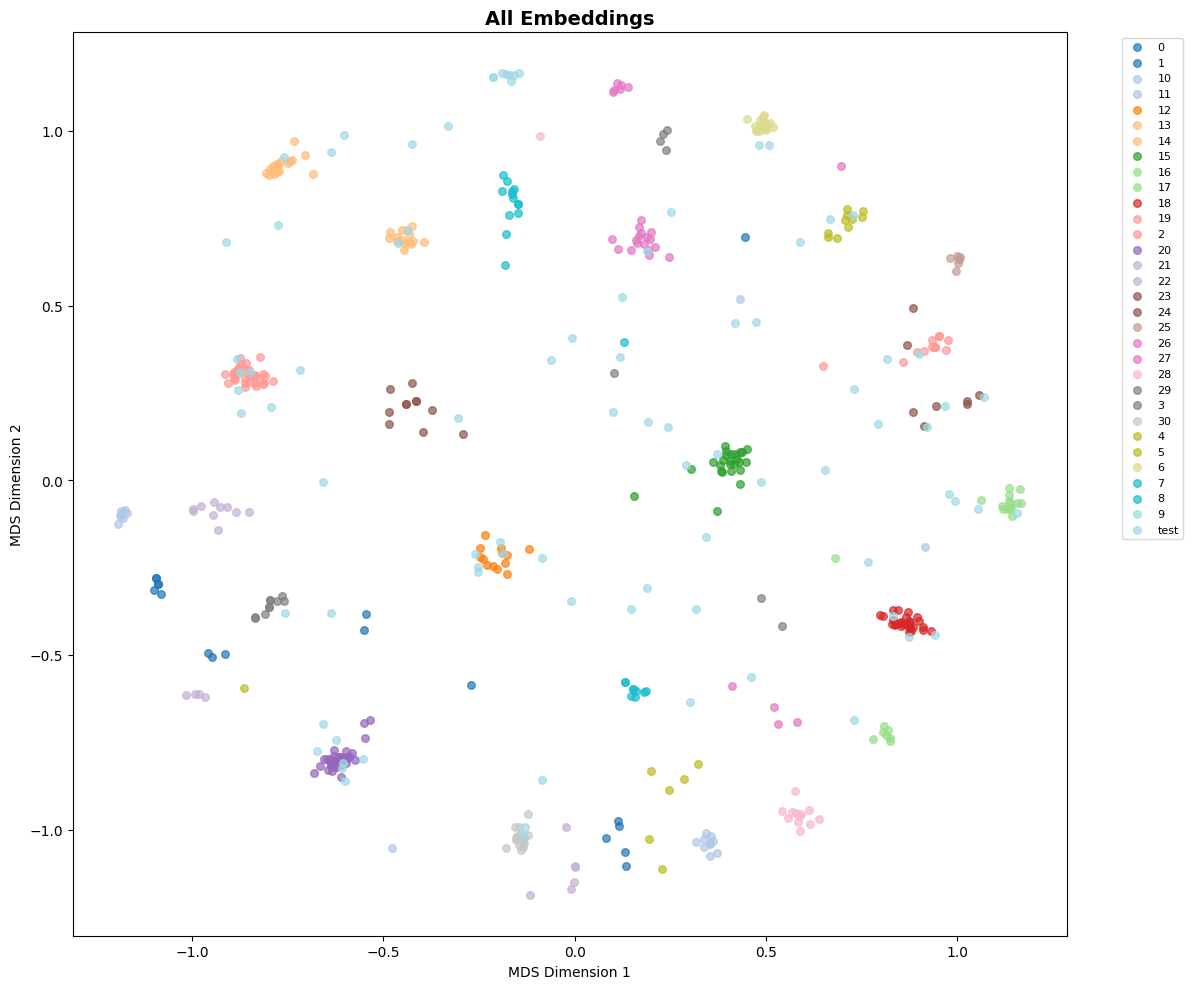

In [ ]:
test_labels = np.array(["test"] * len(test_images))
all_embeddings = np.concatenate([finetuned_embeddings, test_finetuned_embeddings], axis=0)
train_and_test_labels = np.concatenate([all_labels, test_labels], axis=0)

fig_finetuned = visualize_embeddings_mds(
    all_embeddings,
    train_and_test_labels,
    "All Embeddings",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "embeddings_mds_all.png")
plt.show()

# Log to W&B
wandb.log({"all_embeddings_mds": wandb.Image(fig_finetuned)})

We plot the new calulcated distances for reranking.

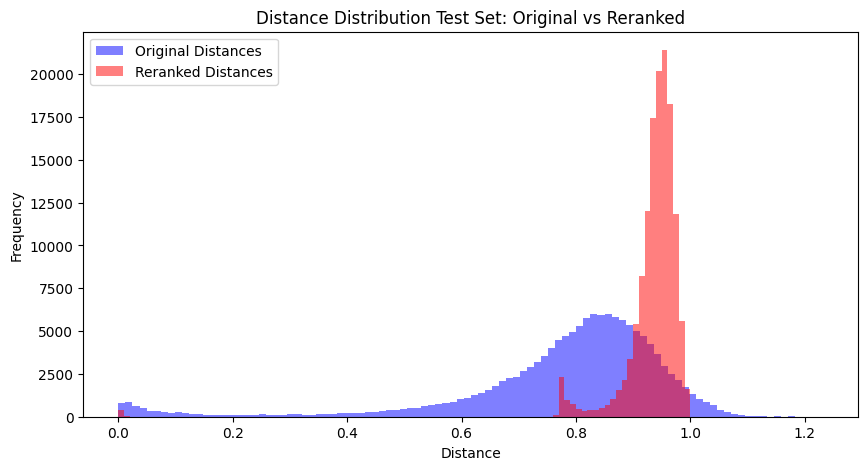

In [ ]:
original_test_dist = cosine_distances(test_finetuned_embeddings, test_finetuned_embeddings)
distance_matrix = k_reciprocal_rerank(
    all_embeddings,
    k1=best_k1,
    k2=best_k2,
    lambda_value=best_lambda
)
reranked_test_dist = distance_matrix[len(baseline_embeddings):, len(baseline_embeddings):]


# Flatten the distance matrices to 1D arrays for plotting
original_flat = original_test_dist.flatten()
reranked_flat = reranked_test_dist.flatten()

# Plot histogram
fig = plt.figure(figsize=(10, 5))
plt.hist(original_flat, bins=100, alpha=0.5, label='Original Distances', color='blue')
plt.hist(reranked_flat, bins=100, alpha=0.5, label='Reranked Distances', color='red')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distance Distribution Test Set: Original vs Reranked')
plt.legend()
plt.show()

wandb.log({"distance_distribution_test_set": wandb.Image(fig)})

In [ ]:
# Compute similarity for each pairall_embeddings
print("Computing pairwise similarities...")
similarities = []

if rerank:
    sim_matrix = -reranked_test_dist
else:
    # Compute cosine similarity matrix
    sim_matrix = cosine_similarity(test_finetuned_embeddings)
    np.fill_diagonal(sim_matrix, 1) # self-similarity

print(f"Similarity matrix shape: {sim_matrix.shape}", f"Sim range: [{sim_matrix.min():.4f}, {sim_matrix.max():.4f}]")

for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    query_id = img_to_index[row['query_image']]
    gallery_id = img_to_index[row['gallery_image']]
    similarity = sim_matrix[query_id, gallery_id]
    similarities.append(similarity)

similarities = np.array(similarities)
min_sim, max_sim = similarities.min(), similarities.max()
# Normalize similarities to [0, 1] for better interpretability
similarities = (similarities - min_sim) / (max_sim - min_sim + 1e-8)

print(f"\nSimilarity statistics:")
print(f"  Min: {similarities.min():.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Std: {similarities.std():.4f}")

Computing pairwise similarities...
Similarity matrix shape: (371, 371) Sim range: [-1.0000, 0.0000]


Computing similarities: 100%|██████████| 137270/137270 [00:07<00:00, 17975.04it/s]


Similarity statistics:
  Min: 0.0000
  Max: 1.0000
  Mean: 0.0642
  Std: 0.0491


In [ ]:
# Create submission DataFrame
submission_df = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

print("Submission DataFrame:")
print(submission_df.head(10))

# Verify format matches sample submission
sample_submission = pd.read_csv(DATA_PATH / "sample_submission.csv")
print(f"\nFormat check:")
print(f"  Expected columns: {list(sample_submission.columns)}")
print(f"  Our columns: {list(submission_df.columns)}")
print(f"  Expected rows: {len(sample_submission)}")
print(f"  Our rows: {len(submission_df)}")

Submission DataFrame:
   row_id  similarity
0       0    0.164307
1       1    0.098798
2       2    0.172525
3       3    0.082929
4       4    0.086645
5       5    0.148741
6       6    0.134800
7       7    0.131957
8       8    0.104140
9       9    0.118582

Format check:
  Expected columns: ['row_id', 'similarity']
  Our columns: ['row_id', 'similarity']
  Expected rows: 137270
  Our rows: 137270


In [ ]:
# Save submission
submission_path = OUTPUT_PATH / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")

Submission saved to: /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/09_reranking/submission.csv
File size: 3526.4 KB


## Artifacts

In [ ]:
# Save model as W&B artifact
model_artifact = wandb.Artifact(
    name=f"model",
    type="model",
    description="Center + ProxyAnchor fine-tuned MegaDescriptor model for jaguar re-identification"
)
model_artifact.add_file(checkpoint_path)
wandb.log_artifact(model_artifact)

print("Model artifact saved to W&B")

Model artifact saved to W&B


In [ ]:
# Save submission as W&B artifact
submission_artifact = wandb.Artifact(
    name="submission",
    type="submission",
    description=f"Competition submission file with reranked = {rerank}"
)
submission_artifact.add_file(str(submission_path))
wandb.log_artifact(submission_artifact)

print("Submission artifact saved to W&B")

Submission artifact saved to W&B


In [ ]:
wandb.finish()

best_epoch,▁
best_reranking_k1,▁
best_reranking_k2,▁
best_reranking_lambda,▁
best_reranking_val_mAP,▁
dino_embedding_dim,▁
dino_num_params,▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇██
final_val_mAP,▁
learning_rate,▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▅▅▅▆▆▆▆▇▇▇▇▇█████████
+8,...
